# Import Required Libraries
This section imports all necessary libraries for SVM training and evaluation, including numpy, pandas, scikit-learn, matplotlib, and joblib.

In [47]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import joblib

# Load and Prepare Dataset
Load the quantum kernel matrix and the preprocessed data. Use the same random sample of 50 rows that was used to compute the kernel matrix.

In [ ]:
# Load quantum kernel matrix (remove header row)
kernel_matrix_raw = np.loadtxt('quantum_kernel_matrix.csv', delimiter=',', skiprows=1)

# Load labels from preprocessed data — use the SAME random sample as the kernel computation
data = pd.read_csv('preprocessed data.csv').sample(n=50, random_state=42).reset_index(drop=True)
labels = data['diagnosis'].map({'M': 1, 'B': 0}).values

# Normalize kernel matrix to correct noisy diagonal: K'[i,j] = K[i,j] / sqrt(K[i,i] * K[j,j])
diag = np.sqrt(np.diag(kernel_matrix_raw))
kernel_matrix = kernel_matrix_raw / np.outer(diag, diag)

print(f"Kernel matrix shape: {kernel_matrix.shape}")
print(f"Class distribution — M(1): {sum(labels==1)}, B(0): {sum(labels==0)}")
print(f"Kernel diagonal (before normalization) min={np.diag(kernel_matrix_raw).min():.4f}, max={np.diag(kernel_matrix_raw).max():.4f}")
print(f"Kernel diagonal (after  normalization) min={np.diag(kernel_matrix).min():.4f}, max={np.diag(kernel_matrix).max():.4f}")

# Split Data into Training and Test Sets
Split the data into training and test sets using an 80-20 ratio, stratified by the labels.

In [49]:
# Train-test split (80-20)
num_samples = kernel_matrix.shape[0]
indices = np.arange(num_samples)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels[:num_samples])

# Prepare kernel matrices for SVM
K_train = kernel_matrix[np.ix_(train_idx, train_idx)]
K_test = kernel_matrix[np.ix_(test_idx, train_idx)]
y_train = labels[train_idx]
y_test = labels[test_idx]

# Train SVM Model
Train the SVM classifier using the precomputed quantum kernel matrix.

In [50]:
# Train SVM with precomputed kernel
svm = SVC(kernel='precomputed')
svm.fit(K_train, y_train)

SVC(kernel='precomputed')

# Evaluate Model Performance
Evaluate the SVM model using accuracy and save the trained model for later use.

In [51]:
# Predict and calculate accuracy
y_pred = svm.predict(K_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Save the trained model
joblib.dump(svm, 'svm_model.joblib')

Test Accuracy: 0.9000


['svm_model.joblib']

# Visualize Results
Visualize the support vectors and the data points using the first two principal components (PC1 and PC2).

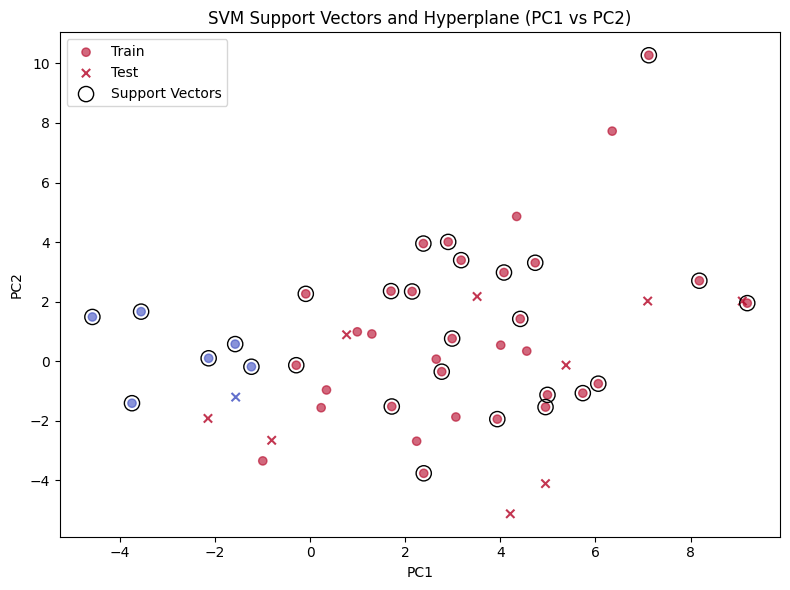

In [52]:
# Visualize support vectors and data points
plt.figure(figsize=(8,6))
X_pc = data[['PC1', 'PC2']].values
plt.scatter(X_pc[train_idx,0], X_pc[train_idx,1], c=y_train, cmap='coolwarm', label='Train', alpha=0.6)
plt.scatter(X_pc[test_idx,0], X_pc[test_idx,1], c=y_test, cmap='coolwarm', marker='x', label='Test', alpha=0.8)

# Highlight support vectors
support_idx = train_idx[svm.support_]
plt.scatter(X_pc[support_idx,0], X_pc[support_idx,1], s=120, facecolors='none', edgecolors='k', label='Support Vectors')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('SVM Support Vectors and Hyperplane (PC1 vs PC2)')
plt.legend()
plt.tight_layout()
plt.savefig('svm_support_vectors.png')
plt.show()

# Run SVM on Multiple Splits
Evaluate the SVM model on multiple random train-test splits and display each split's accuracy. Uses local variables to avoid overwriting the main train/test split.

In [ ]:
# Run SVM on multiple splits and display all accuracies
# Uses prefixed variable names to avoid overwriting the main split
from tqdm import tqdm

n_splits = 20
accuracies = []

for seed in tqdm(range(n_splits)):
    sp_train_idx, sp_test_idx = train_test_split(
        indices, test_size=0.2, random_state=seed, stratify=labels[:num_samples]
    )
    sp_K_train = kernel_matrix[np.ix_(sp_train_idx, sp_train_idx)]
    sp_K_test = kernel_matrix[np.ix_(sp_test_idx, sp_train_idx)]
    sp_y_train = labels[sp_train_idx]
    sp_y_test = labels[sp_test_idx]

    sp_svm = SVC(kernel='precomputed')
    sp_svm.fit(sp_K_train, sp_y_train)
    sp_y_pred = sp_svm.predict(sp_K_test)
    acc = accuracy_score(sp_y_test, sp_y_pred)
    accuracies.append(acc)
    print(f"Split {seed+1}: Accuracy = {acc:.4f}")

# Display results table and summary stats
results_df = pd.DataFrame({'Split': range(1, n_splits+1), 'Accuracy': accuracies})
display(results_df)
print(f"\nMean Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Min: {np.min(accuracies):.4f}, Max: {np.max(accuracies):.4f}")

100%|██████████| 20/20 [00:00<00:00, 1073.70it/s]

Split 1: Accuracy = 0.9000
Split 2: Accuracy = 0.9000
Split 3: Accuracy = 0.9000
Split 4: Accuracy = 0.9000
Split 5: Accuracy = 0.9000
Split 6: Accuracy = 0.9000
Split 7: Accuracy = 0.9000
Split 8: Accuracy = 0.9000
Split 9: Accuracy = 0.9000
Split 10: Accuracy = 0.9000
Split 11: Accuracy = 0.9000
Split 12: Accuracy = 0.9000
Split 13: Accuracy = 0.9000
Split 14: Accuracy = 0.9000
Split 15: Accuracy = 0.9000
Split 16: Accuracy = 0.9000
Split 17: Accuracy = 0.9000
Split 18: Accuracy = 0.9000
Split 19: Accuracy = 0.9000
Split 20: Accuracy = 0.9000


,Split,Accuracy
0,1,0.9
1,2,0.9
2,3,0.9
3,4,0.9
4,5,0.9
5,6,0.9
6,7,0.9
7,8,0.9
8,9,0.9
9,10,0.9
